# Lesson 17 — COCO / BBOB Benchmark

The **COCO framework** provides 24 noiseless black-box benchmark functions (the **BBOB suite**) that cover a wide range of landscape types: smooth, ill-conditioned, deceptive, and multimodal.

We use `cocoex` to access the functions, run our SCR-enforced BO, and evaluate performance with a **COCO-style performance profile** — a standard tool for comparing optimisers.

**Key metric:** fraction of (seed, target) pairs solved within a given true-call budget.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import norm as sp_norm
from scipy.optimize import minimize as sp_minimize
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import RBFInterpolator
import cocoex

warnings.filterwarnings('ignore')

RANDOM_SEED  = 42
INSTANCE     = 1
FUNC_IDS     = [1, 2, 8, 15]
FUNC_NAMES   = ['Sphere (f1)', 'Ellipsoidal (f2)', 'Rosenbrock (f8)', 'Rastrigin (f15)']
FUNC_SHORT   = ['Sphere', 'Ellipsoidal', 'Rosenbrock', 'Rastrigin']
DIM_MAIN     = 2
DIM_HD       = 5
N_INIT       = 10
N_INIT_HD    = 15
N_ITER       = 15
N_SEEDS      = 3
N_SEEDS_MF   = 2
EPOCHS_BO    = 100
N_MEMBERS    = 5
T_DROPOUT    = 50
SCR_MAX      = 0.20
TARGETS      = [10.0, 1.0, 0.1, 0.01]

SURROGATES = ['gp', 'mc_dropout', 'deep_ensemble', 'rbf', 'rf']
LABELS     = ['GP', 'MC Dropout', 'Deep Ensemble', 'RBF', 'Random Forest']
COLORS     = ['steelblue', 'seagreen', 'darkorange', 'tomato', 'purple']

print(f'cocoex version: {cocoex.__version__}')

cocoex version: 2.8.2


## BBOB function wrapper

`cocoex` functions operate on [−5, 5]^d. We wrap them to accept inputs in [0, 1]^d so our existing BO code works unchanged.

`find_fopt` uses multi-start scipy.minimize to approximate the global optimum — this is needed because each BBOB instance has a random offset that shifts the optimum location.

In [2]:
def make_bbob(func_id, dim, instance=INSTANCE):
    suite = cocoex.Suite(
        'bbob',
        f'instances:{instance}',
        f'dimensions:{dim} function_indices:{func_id}',
    )
    f  = suite[0]
    lb = f.lower_bounds.copy()
    ub = f.upper_bounds.copy()

    def wrapped(x):
        return float(f(lb + np.asarray(x).ravel() * (ub - lb)))

    wrapped._alive = (suite, f)
    return wrapped


def find_fopt(func, dim, n_restarts=20):
    rng  = np.random.RandomState(RANDOM_SEED)
    best = np.inf
    for _ in range(n_restarts):
        res = sp_minimize(
            func, rng.rand(dim), method='L-BFGS-B',
            bounds=[(1e-6, 1-1e-6)] * dim,
            options={'maxiter': 10000, 'ftol': 1e-15},
        )
        best = min(best, res.fun)
    return best


# Quick check
for fid, fname in zip(FUNC_IDS, FUNC_NAMES):
    fopt = find_fopt(make_bbob(fid, DIM_MAIN), DIM_MAIN)
    print(f'{fname}: f_opt ≈ {fopt:.4f}')

Sphere (f1): f_opt ≈ 79.4800
Ellipsoidal (f2): f_opt ≈ -209.8800
Rosenbrock (f8): f_opt ≈ 149.1500
Rastrigin (f15): f_opt ≈ 1001.9899


## Neural network and surrogate implementations

Same unified interface as Lessons 14–16.

In [3]:
class Net(nn.Module):
    def __init__(self, d_in, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 64),   nn.ReLU(), nn.Dropout(p),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_net(X, y, epochs, seed):
    torch.manual_seed(seed)
    model = Net(X.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xt    = torch.tensor(X, dtype=torch.float32)
    yt    = torch.tensor(y, dtype=torch.float32)
    model.train()
    for _ in range(epochs):
        opt.zero_grad()
        nn.MSELoss()(model(Xt), yt).backward()
        opt.step()
    return model


def surrogate_predict(stype, X_tr, y_tr, X_cand, seed=0, epochs=100):
    torch.manual_seed(seed)

    if stype == 'gp':
        kernel = Matern(nu=2.5, length_scale_bounds=(1e-3, 10.0))
        gpr = GaussianProcessRegressor(
            kernel=kernel, alpha=1e-4,
            n_restarts_optimizer=2, normalize_y=True, random_state=seed,
        )
        gpr.fit(X_tr, y_tr)
        mu, std = gpr.predict(X_cand, return_std=True)
        return mu, np.maximum(std, 1e-8)

    if stype == 'mc_dropout':
        model = train_net(X_tr, y_tr, epochs, seed)
        model.train()
        Xc = torch.tensor(X_cand, dtype=torch.float32)
        with torch.no_grad():
            preds = np.stack([model(Xc).numpy() for _ in range(T_DROPOUT)])
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    if stype == 'deep_ensemble':
        preds = []
        for i in range(N_MEMBERS):
            m  = train_net(X_tr, y_tr, epochs, seed + i * 17)
            m.eval()
            Xc = torch.tensor(X_cand, dtype=torch.float32)
            with torch.no_grad():
                preds.append(m(Xc).numpy())
        preds = np.stack(preds)
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    if stype == 'rbf':
        rbf = RBFInterpolator(X_tr, y_tr, kernel='thin_plate_spline', smoothing=1e-3)
        mu  = rbf(X_cand)
        diffs = X_cand[:, None, :] - X_tr[None, :, :]
        min_d = np.linalg.norm(diffs, axis=-1).min(axis=1)
        std   = min_d / (min_d.max() + 1e-8) + 0.05
        return mu, std

    if stype == 'rf':
        rf = RandomForestRegressor(n_estimators=100, random_state=seed)
        rf.fit(X_tr, y_tr)
        preds = np.stack([t.predict(X_cand) for t in rf.estimators_])
        return preds.mean(0), np.maximum(preds.std(0), 1e-8)

    raise ValueError(f'Unknown surrogate: {stype}')

## SCR-enforced BO loop

Unchanged from Lessons 13–16. The only difference is that the objective function is now a wrapped BBOB function.

In [4]:
def ei(mu, std, best, xi=0.01):
    imp = best - mu - xi
    z   = imp / (std + 1e-8)
    return imp * sp_norm.cdf(z) + std * sp_norm.pdf(z)


def run_bo(stype, func, dim, seed, f_opt,
           n_init, n_iter, epochs=EPOCHS_BO, scr_max=SCR_MAX):
    rng = np.random.RandomState(seed)
    sampler = LatinHypercube(d=dim, seed=seed)
    X_obs   = sampler.random(n_init)
    y_obs   = np.array([func(x) for x in X_obs])

    true_calls = n_init
    surr_calls = 0
    best_true  = y_obs.min()
    history    = [(true_calls, max(best_true - f_opt, 0.0))]

    for _ in range(n_iter):
        y_mean = y_obs.mean()
        y_sc   = y_obs.std() + 1e-8
        y_std  = (y_obs - y_mean) / y_sc

        X_cand      = rng.rand(200, dim)
        mu_s, sig_s = surrogate_predict(stype, X_obs, y_std, X_cand, seed, epochs)
        mu          = mu_s  * y_sc + y_mean
        sig         = sig_s * y_sc

        acq             = ei(mu, sig, best_true)
        idx             = np.argmax(acq)
        x_next, mu_next = X_cand[idx], mu[idx]

        proj     = (surr_calls + 1) / (true_calls + surr_calls + 1)
        use_surr = (scr_max > 0) and (proj <= scr_max)

        if use_surr:
            y_next = mu_next
            surr_calls += 1
        else:
            y_next = func(x_next)
            true_calls += 1
            best_true = min(best_true, y_next)

        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, y_next)
        history.append((true_calls, max(best_true - f_opt, 0.0)))

    return history


def run_seeds(stype, func, dim, f_opt, n_init, n_iter, n_seeds, epochs=EPOCHS_BO):
    return [
        run_bo(stype, func, dim, RANDOM_SEED + s, f_opt,
               n_init=n_init, n_iter=n_iter, epochs=epochs)
        for s in range(n_seeds)
    ]


def final_gap(hists):
    return float(np.median([h[-1][1] for h in hists]))


def plot_convergence(ax, results_by_stype, n_init, title):
    for stype, label, color in zip(SURROGATES, LABELS, COLORS):
        hists  = results_by_stype[stype]
        max_tc = max(h[-1][0] for h in hists)
        grid   = np.arange(n_init, max_tc + 1)
        runs   = np.array([
            np.interp(grid, [h[0] for h in hist], [h[1] for h in hist])
            for hist in hists
        ])
        med = np.median(runs, axis=0)
        lo  = np.percentile(runs, 25, axis=0)
        hi  = np.percentile(runs, 75, axis=0)
        ax.semilogy(grid, np.maximum(med, 1e-6), color=color, label=label, lw=2)
        ax.fill_between(grid, np.maximum(lo, 1e-6), np.maximum(hi, 1e-6),
                        alpha=0.2, color=color)
    ax.set_xlabel('True function calls')
    ax.set_ylabel('Gap to optimum (log scale)')
    ax.set_title(title)
    ax.legend(fontsize=9)

---
## Part 1 — BBOB function gallery

2D contour plots of all four functions in the native [−5, 5]² domain.

- **Sphere**: smooth bowl — easy for all surrogates
- **Ellipsoidal**: elongated bowl — tests surrogate sensitivity to scale differences
- **Rosenbrock**: narrow curved valley — easy to find the valley, hard to follow it
- **Rastrigin**: regular grid of local minima — multimodal, hardest for GP

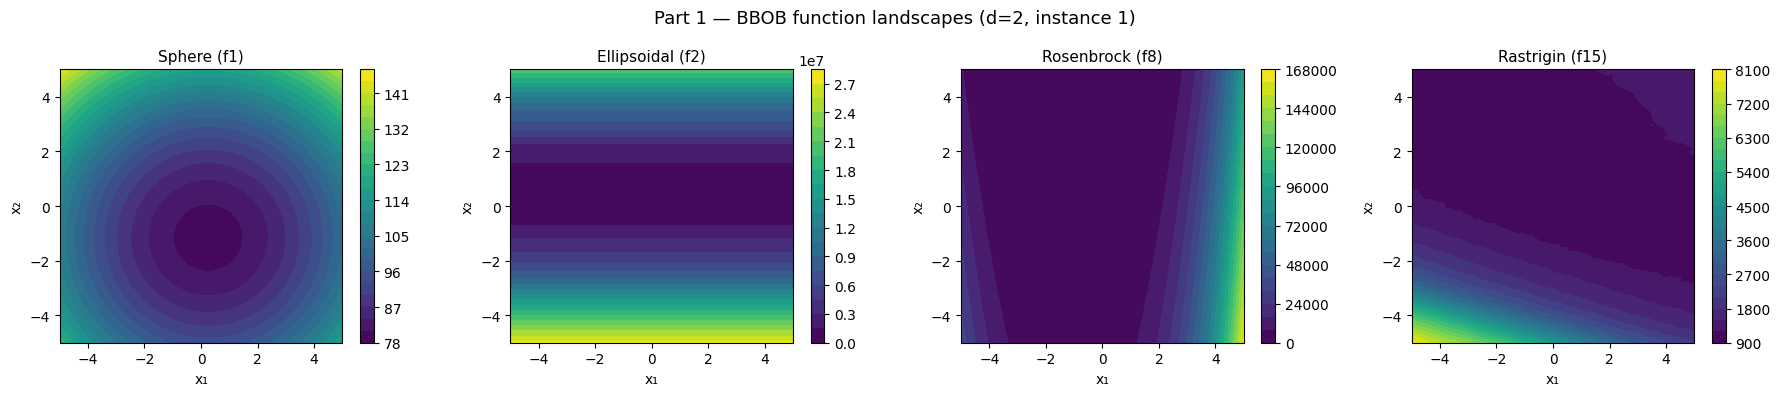

In [5]:
grid   = np.linspace(0, 1, 60)
Xg, Yg = np.meshgrid(grid, grid)
pts    = np.column_stack([Xg.ravel(), Yg.ravel()])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, fid, fname in zip(axes, FUNC_IDS, FUNC_NAMES):
    func = make_bbob(fid, 2)
    Z    = np.array([func(p) for p in pts]).reshape(60, 60)
    im   = ax.contourf(Xg*10 - 5, Yg*10 - 5, Z, levels=25, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title(fname, fontsize=11)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')

fig.suptitle('Part 1 — BBOB function landscapes (d=2, instance 1)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 2 — Convergence on Sphere (f1, d=2)

Sphere is unimodal and separable — the easiest BBOB function. Every surrogate should converge well here.

This serves as a **sanity check**: if a surrogate struggles on Sphere, something is wrong.

Finding f_opt for Sphere (f1, d=2)...
  f_opt ≈ 79.4800
Running BO on Sphere...
  GP...
  MC Dropout...
  Deep Ensemble...
  RBF...
  Random Forest...


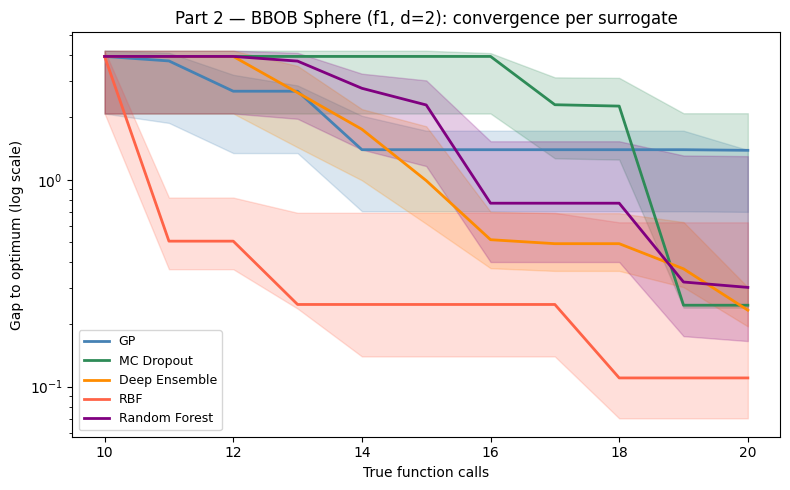

In [6]:
print('Finding f_opt for Sphere (f1, d=2)...')
f_opt_sphere = find_fopt(make_bbob(1, DIM_MAIN), DIM_MAIN)
print(f'  f_opt ≈ {f_opt_sphere:.4f}')

print('Running BO on Sphere...')
sphere_func = make_bbob(1, DIM_MAIN)
sphere_d2   = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    sphere_d2[stype] = run_seeds(stype, sphere_func, DIM_MAIN,
                                  f_opt_sphere, N_INIT, N_ITER, N_SEEDS)

fig, ax = plt.subplots(figsize=(8, 5))
plot_convergence(ax, sphere_d2, N_INIT,
                 'Part 2 — BBOB Sphere (f1, d=2): convergence per surrogate')
plt.tight_layout()
plt.show()

---
## Part 3 — Performance profile (f1, d=2)

A **performance profile** measures *how quickly* each surrogate solves problems at various precision levels.

For each (seed, target τ) pair:
- **Solved** = gap fell below τ within the budget
- **x-axis** = true function calls
- **y-axis** = fraction of all (seed, target) pairs solved

Targets: τ ∈ {10, 1, 0.1, 0.01}. A surrogate that rises faster to 1.0 is better overall.

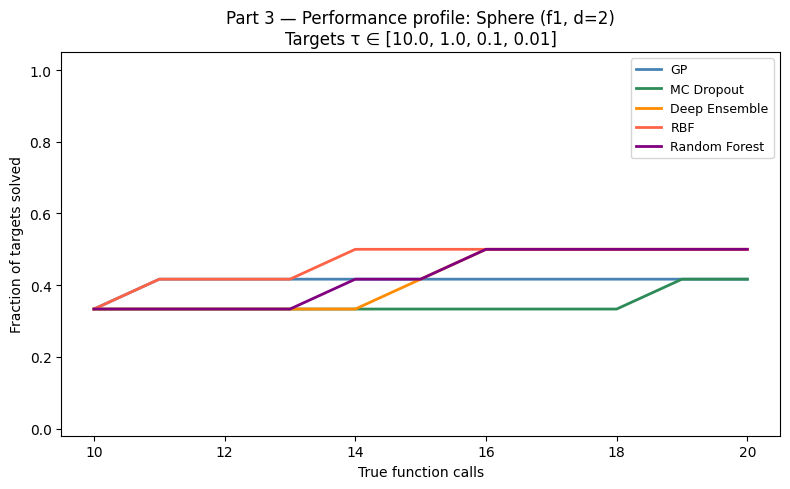

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for stype, label, color in zip(SURROGATES, LABELS, COLORS):
    hists   = sphere_d2[stype]
    max_tc  = max(h[-1][0] for h in hists)
    budgets = np.arange(N_INIT, max_tc + 1)

    solved = []
    for hist in hists:
        for tau in TARGETS:
            hits = [h[0] for h in hist if h[1] < tau]
            solved.append(hits[0] if hits else np.inf)
    solved = np.array(solved)
    frac   = np.array([np.mean(solved <= b) for b in budgets])

    ax.plot(budgets, frac, color=color, label=label, lw=2)

ax.set_xlabel('True function calls')
ax.set_ylabel('Fraction of targets solved')
ax.set_title(f'Part 3 — Performance profile: Sphere (f1, d=2)\nTargets τ ∈ {TARGETS}')
ax.legend(fontsize=9)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

---
## Part 4 — Multi-function heatmap

Run all 5 surrogates on all 4 BBOB functions. The heatmap shows log₁₀(final gap) — green cells are better (lower gap).

**Questions to explore:**
- Which function is hardest for all surrogates?
- Is there any surrogate that performs well on Rastrigin (multimodal)?

Finding f_opts for all functions...
  Sphere (f1): f_opt ≈ 79.4800
  Ellipsoidal (f2): f_opt ≈ -209.8800
  Rosenbrock (f8): f_opt ≈ 149.1500
  Rastrigin (f15): f_opt ≈ 1001.9899
Running multi-function BO...
  Sphere (f1) × GP...
  Sphere (f1) × MC Dropout...
  Sphere (f1) × Deep Ensemble...
  Sphere (f1) × RBF...
  Sphere (f1) × Random Forest...
  Ellipsoidal (f2) × GP...
  Ellipsoidal (f2) × MC Dropout...
  Ellipsoidal (f2) × Deep Ensemble...
  Ellipsoidal (f2) × RBF...
  Ellipsoidal (f2) × Random Forest...
  Rosenbrock (f8) × GP...
  Rosenbrock (f8) × MC Dropout...
  Rosenbrock (f8) × Deep Ensemble...
  Rosenbrock (f8) × RBF...
  Rosenbrock (f8) × Random Forest...
  Rastrigin (f15) × GP...
  Rastrigin (f15) × MC Dropout...
  Rastrigin (f15) × Deep Ensemble...
  Rastrigin (f15) × RBF...
  Rastrigin (f15) × Random Forest...


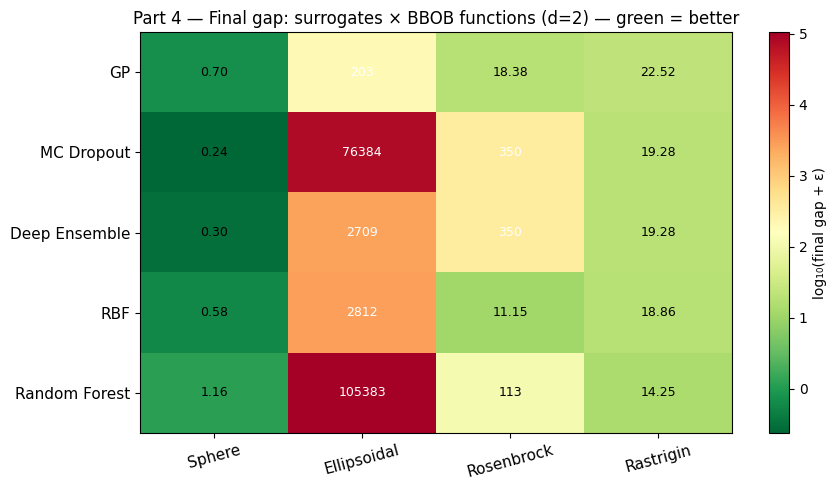

In [8]:
print('Finding f_opts for all functions...')
f_opts = {}
for fid, fname in zip(FUNC_IDS, FUNC_NAMES):
    f_opts[fid] = find_fopt(make_bbob(fid, DIM_MAIN), DIM_MAIN)
    print(f'  {fname}: f_opt ≈ {f_opts[fid]:.4f}')

print('Running multi-function BO...')
mf_results = {}
for fid, fname in zip(FUNC_IDS, FUNC_NAMES):
    mf_results[fid] = {}
    func = make_bbob(fid, DIM_MAIN)
    for stype, label in zip(SURROGATES, LABELS):
        print(f'  {fname} × {label}...')
        mf_results[fid][stype] = run_seeds(
            stype, func, DIM_MAIN, f_opts[fid], N_INIT, N_ITER, N_SEEDS_MF)

gap_mat = np.array([
    [final_gap(mf_results[fid][stype]) for fid in FUNC_IDS]
    for stype in SURROGATES
])
log_gap = np.log10(gap_mat + 1e-6)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(log_gap, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, ax=ax, label='log₁₀(final gap + ε)')
ax.set_xticks(range(len(FUNC_IDS)))
ax.set_xticklabels(FUNC_SHORT, rotation=15, fontsize=11)
ax.set_yticks(range(len(SURROGATES)))
ax.set_yticklabels(LABELS, fontsize=11)
for i in range(len(SURROGATES)):
    for j in range(len(FUNC_IDS)):
        v   = gap_mat[i, j]
        txt = f'{v:.2f}' if v < 100 else f'{v:.0f}'
        fg  = 'white' if log_gap[i,j] > (log_gap.min()+log_gap.max())/2 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=fg)
ax.set_title('Part 4 — Final gap: surrogates × BBOB functions (d=2) — green = better')
plt.tight_layout()
plt.show()

---
## Part 5 — Dimension scaling (Sphere: d=2 vs d=5)

Run all surrogates on the Sphere function at d=2 and d=5 with more initial points (15 for d=5).

Solid bars = d=2, hatched bars = d=5. The ratio reveals which surrogate is most sensitive to the curse of dimensionality.

In [ ]:
print('Running Sphere at d=5...')
f_opt_d5     = find_fopt(make_bbob(1, DIM_HD), DIM_HD)
sphere_func5 = make_bbob(1, DIM_HD)
sphere_d5    = {}
for stype, label in zip(SURROGATES, LABELS):
    print(f'  {label}...')
    sphere_d5[stype] = run_seeds(stype, sphere_func5, DIM_HD,
                                  f_opt_d5, N_INIT_HD, N_ITER, N_SEEDS_MF)

gaps_d2 = [final_gap(sphere_d2[s]) for s in SURROGATES]
gaps_d5 = [final_gap(sphere_d5[s]) for s in SURROGATES]

x     = np.arange(len(SURROGATES))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, gaps_d2, width, label='d=2', color=COLORS, alpha=0.85)
ax.bar(x + width/2, gaps_d5, width, label='d=5', color=COLORS, alpha=0.45, hatch='///')
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=15)
ax.set_ylabel('Final gap to optimum')
ax.set_title('Part 5 — Dimension scaling: Sphere (f1) at d=2 vs d=5')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## Part 6 — Leaderboard

Rank each surrogate on each BBOB function (1 = best gap, 5 = worst), then average across functions.

The rank heatmap and average rank bar chart together reveal the most consistent surrogate across landscape types.

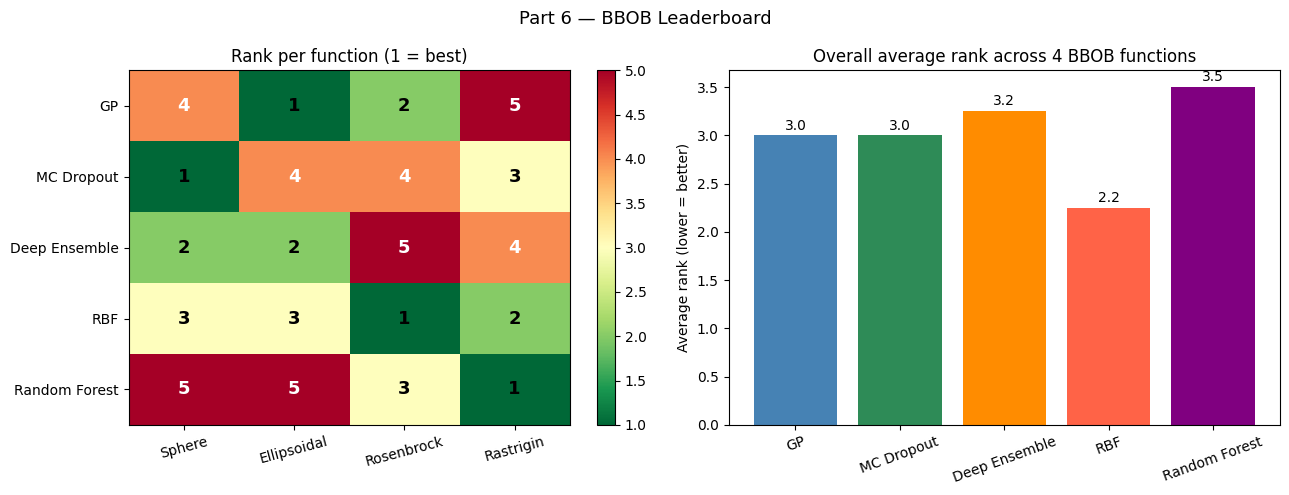

Surrogate            Avg Rank
------------------------------
RBF                      2.25
GP                       3.00
MC Dropout               3.00
Deep Ensemble            3.25
Random Forest            3.50


In [9]:
ranks = np.zeros((len(SURROGATES), len(FUNC_IDS)))
for j, fid in enumerate(FUNC_IDS):
    gaps = [final_gap(mf_results[fid][s]) for s in SURROGATES]
    ranks[:, j] = np.argsort(np.argsort(gaps)) + 1

avg_ranks = ranks.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(ranks, cmap='RdYlGn_r', vmin=1, vmax=len(SURROGATES), aspect='auto')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks(range(len(FUNC_IDS)))
axes[0].set_xticklabels(FUNC_SHORT, rotation=15)
axes[0].set_yticks(range(len(SURROGATES)))
axes[0].set_yticklabels(LABELS)
for i in range(len(SURROGATES)):
    for j in range(len(FUNC_IDS)):
        axes[0].text(j, i, f'{int(ranks[i,j])}', ha='center', va='center',
                     fontsize=13, fontweight='bold',
                     color='white' if ranks[i,j] > 3 else 'black')
axes[0].set_title('Rank per function (1 = best)')

bars = axes[1].bar(LABELS, avg_ranks, color=COLORS)
axes[1].set_ylabel('Average rank (lower = better)')
axes[1].set_title('Overall average rank across 4 BBOB functions')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, avg_ranks):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Part 6 — BBOB Leaderboard', fontsize=13)
plt.tight_layout()
plt.show()

print(f"{'Surrogate':<18} {'Avg Rank':>10}")
print('-' * 30)
for i in np.argsort(avg_ranks):
    print(f'{LABELS[i]:<18} {avg_ranks[i]:>10.2f}')

---
## Exercises

1. **Part 4** — Which BBOB function is hardest for all surrogates? Is this consistent with the landscape character shown in Part 1?

2. **Part 3** — Does GP reach the tightest target (τ=0.01) more reliably than neural network surrogates? What does this say about posterior calibration?

3. **Part 5** — Change `DIM_HD = 10` and re-run Part 5. Which surrogate degrades least? Does this match what you observed in Lesson 15?